# Topological Hexagonal Lattice — Unit-Cell Band Structure (MPB)

This notebook analyzes the hexagonal photonic-crystal lattice from
`11_topological_hexagonal_lattice.ipynb`: each unit cell is a rosette of 6
triangular air holes (3 "type A" + 3 "type B", alternating every 60&deg;), whose
radial position is controlled by a shrink/expand parameter `exsh`. The geometry
algorithm is a **literal translation** of `11_...`'s `draw_unitcell` math into
`mp.Prism` objects — same formulas, same hardcoded 90&deg; global rotation.

**Structural parameters** are taken directly from Section C / Fig. S4 of
Kawaguchi *et al.*, *Sci. Adv.* **10**, eadn6095 (2024) (supplementary
material): `a0 = 3.9 μm`, six equilateral triangles `tA = tB = 1.351 μm`
("spin-Hall" case, same-size triangles, only the *radial position* differs
between domains), with the hexagonal-cluster-center-to-triangle-center distance
1.352 μm (**expanded**, `exsh = 1.352/1.30 = 1.04`) and 1.235 μm
(**shrunken**, `exsh = 1.235/1.30 = 0.95`) — 1.30 μm being the unperturbed
(`exsh=1`) distance `a0/3`. The paper reports the resulting bandgap near
`λ ≈ 7.2 μm`; scaling by our `a0 = 770 nm` gives a target of
`770 nm × (7.2/3.9) ≈ 1421.5 nm`.

This notebook covers **only the MPB unit-cell band structure** (TE, focused on
Γ→K, matching Fig. S4's Γ-point bandgap check). Domain-wall / Meep FDTD work
follows in a separate step once the gap is confirmed here.

## 0. Imports and global parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import meep as mp
from meep import mpb

mp.verbosity(0)   # suppress per-object geometry dumps and solver chatter

%matplotlib inline

In [2]:
# --- Physical / material parameters ---
a0_nm = 770.0                       # our physical lattice constant [nm]
n_si, n_air = 2.66, 1.0             # n_si=2.66 matches the paper's 2D effective-index value (Section D)
eps_si, eps_air = n_si**2, n_air**2

# --- Geometry parameters -- ratios taken directly from paper Section C / Fig. S4 ---
# Paper: a0_paper = 3.9 um, tA = tB = 1.351 um ("spin-Hall" case: same-size triangles,
# domains differ only by radial position exsh). Ratios are scale-invariant, so they
# carry over unchanged to our a0 = 770 nm.
a0_paper_um = 3.9
tA_ratio = 1.351 / a0_paper_um
tB_ratio = 1.351 / a0_paper_um       # tA_ratio == tB_ratio for the spin-Hall pair

# exsh = (hexagon-center-to-triangle-center distance) / (unperturbed distance a0/3)
exsh_expanded = 1.352 / 1.30         # 1.0400
exsh_shrunken = 1.235 / 1.30         # 0.9500  (exact)
exsh_values = [exsh_expanded, exsh_shrunken]   # Domain A ("expanded"), Domain B ("shrunk")

# --- Target wavelength, scaled from the paper's ~7.2 um result at a0=3.9um ---
lambda_target_nm = a0_nm * (7.2 / a0_paper_um)   # ~= 1421.5 nm

# --- MPB parameters ---
mpb_resolution = 32
num_bands = 10
num_kpoints = 29                     # points along the single Gamma -> K segment

print(f"eps_si = {eps_si:.4f}, eps_air = {eps_air:.4f}")
print(f"tA_ratio = tB_ratio = {tA_ratio:.5f}")
print(f"exsh_expanded = {exsh_expanded:.4f}, exsh_shrunken = {exsh_shrunken:.4f}")
print(f"lambda_target_nm = {lambda_target_nm:.1f} nm")

eps_si = 7.0756, eps_air = 1.0000
tA_ratio = tB_ratio = 0.34641
exsh_expanded = 1.0400, exsh_shrunken = 0.9500
lambda_target_nm = 1421.5 nm


## 1. Shared geometry function and Unit Cell

Identical math to `11_topological_hexagonal_lattice.ipynb`'s `draw_unitcell`
(cell 0): same side/height/centroid/rotation formulas and the same hardcoded
90&deg; global rotation, returning `mp.Prism` air-hole objects instead of
matplotlib patches. **This is the only place the hole geometry is defined.**

The visualization below shows exactly the "Unit Rectangle" region from `11_...`
cell 0 (width `a0`, height `sqrt(3)*a0`, centered on one unit cell) — no larger
region than that.

In [3]:
def make_unitcell_geometry(a0, exsh, tA_ratio, tB_ratio,
                            center=mp.Vector3(0, 0, 0), eps_air=eps_air):
    """6 air-hole mp.Prism triangles (3 type A + 3 type B) for one unit cell,
    centered at `center`. Identical math to 11_...'s draw_unitcell (cell 0)."""
    side_large = a0 / np.sqrt(3)
    tA = tA_ratio * a0
    tB = tB_ratio * a0
    height_large = side_large * np.sqrt(3) / 2
    height_smallA = tA * np.sqrt(3) / 2
    height_smallB = tB * np.sqrt(3) / 2
    centroid_y = -(2 / 3) * height_large

    def get_small_coords(side, height):
        x = np.array([0, -side / 2, side / 2, 0])
        y = np.array([
            centroid_y * exsh + (2 / 3) * height,
            centroid_y * exsh - (1 / 3) * height,
            centroid_y * exsh - (1 / 3) * height,
            centroid_y * exsh + (2 / 3) * height,
        ])
        return np.vstack((x, y))

    coords_smallA = get_small_coords(tA, height_smallA)
    coords_smallB = get_small_coords(tB, height_smallB)

    def rot(angle_rad):
        c, s = np.cos(angle_rad), np.sin(angle_rad)
        return np.array([[c, -s], [s, c]])

    global_shift_rad = np.radians(90)   # hardcoded exactly as in 11_...
    R_global = rot(global_shift_rad)
    angles = [60, 120, 180, 240, 300, 360]
    prisms = []
    for angle_deg in angles:
        R_total = R_global @ rot(np.radians(angle_deg))
        pts = R_total @ (coords_smallA if angle_deg in (60, 180, 300) else coords_smallB)
        verts = [mp.Vector3(pts[0, i] + center.x, pts[1, i] + center.y, 0)
                 for i in range(pts.shape[1])]
        prisms.append(mp.Prism(verts, height=mp.inf, axis=mp.Vector3(0, 0, 1),
                                material=mp.Medium(epsilon=eps_air)))
    return prisms


# Lattice vectors, matching 11_...: a1 = (a0, 0), a2 = (a0/2, sqrt(3)/2 * a0)
geometry_lattice = mp.Lattice(size=mp.Vector3(1, 1, 0),
                               basis1=mp.Vector3(1, 0, 0),
                               basis2=mp.Vector3(0.5, np.sqrt(3) / 2, 0))

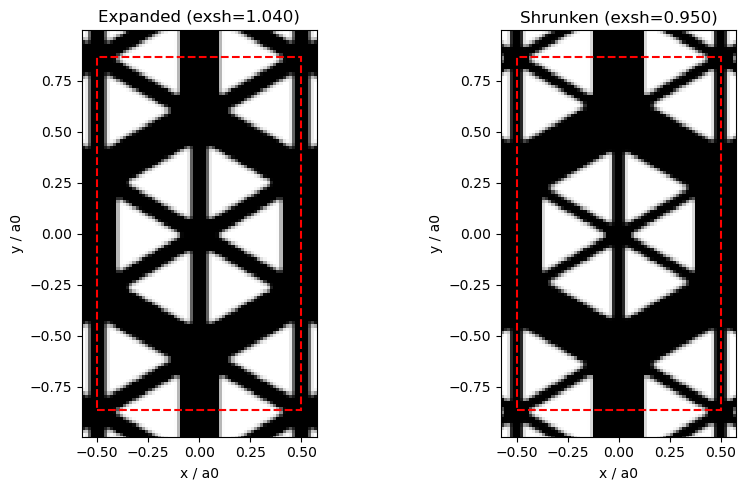

In [4]:
def tile_unitcells(a0, exsh, tA_ratio, tB_ratio, Nx, Ny, eps_air=eps_air):
    """Tile Nx x Ny copies of one unit cell using 11_...'s row-offset scheme
    (shift_factor=-(m//2)) -- used only to render enough geometry around the
    displayed Unit Rectangle so edge triangles aren't clipped.

    Centering matches 11_...'s cell 0: rather than centering on the naive
    bounding-box average (which generally falls *between* lattice points, not
    on one), we center on the actual lattice point nearest that average --
    exactly 11_...'s "closest unit cell to the origin" logic. This guarantees
    a real rosette (triangle cluster) center sits exactly at (0, 0), not some
    arbitrary point between two rosettes.
    """
    side_large = a0 / np.sqrt(3)
    a1x, a1y = a0, 0.0
    a2x, a2y = a0 / 2.0, 1.5 * side_large
    raw = []
    for m in range(Ny):
        shift_factor = -(m // 2)
        for n in range(Nx):
            tx = (n + shift_factor) * a1x + m * a2x
            ty = n * a1y + m * a2y
            raw.append((tx, ty))
    xs, ys = zip(*raw)
    bbox_cx, bbox_cy = (min(xs) + max(xs)) / 2.0, (min(ys) + max(ys)) / 2.0
    cx0, cy0 = min(raw, key=lambda p: (p[0] - bbox_cx)**2 + (p[1] - bbox_cy)**2)
    geometry = []
    for tx, ty in raw:
        geometry += make_unitcell_geometry(a0, exsh, tA_ratio, tB_ratio,
                                            center=mp.Vector3(tx - cx0, ty - cy0, 0), eps_air=eps_air)
    size = mp.Vector3((max(xs) - min(xs)) + 2 * a0, (max(ys) - min(ys)) + 2 * a0, 0)
    return geometry, size


def plot_unitcell(ax, exsh, title):
    """Render exactly the 'Unit Rectangle' (width a0, height sqrt(3)*a0) from
    11_...'s cell 0, cropped to that region -- no larger tiling shown."""
    geometry, size = tile_unitcells(1.0, exsh, tA_ratio, tB_ratio, 3, 3)
    sim = mp.Simulation(cell_size=size, resolution=64, geometry=geometry,
                         default_material=mp.Medium(epsilon=eps_si), dimensions=2)
    sim.init_sim()
    eps = sim.get_array(center=mp.Vector3(0, 0, 0), size=size, component=mp.Dielectric)
    extent = [-size.x / 2, size.x / 2, -size.y / 2, size.y / 2]
    ax.imshow(eps.T, extent=extent, origin='lower', cmap='binary')

    rect_width, rect_height = 1.0, np.sqrt(3)          # a0 x sqrt(3)*a0, matching 11_... cell 0
    ax.add_patch(patches.Rectangle((-rect_width / 2, -rect_height / 2), rect_width, rect_height,
                                    linewidth=1.5, linestyle='--', edgecolor='red', facecolor='none'))
    ax.set_xlim(-rect_width / 2 * 1.15, rect_width / 2 * 1.15)
    ax.set_ylim(-rect_height / 2 * 1.15, rect_height / 2 * 1.15)
    ax.set_aspect('equal')
    ax.set_xlabel('x / a0')
    ax.set_ylabel('y / a0')
    ax.set_title(title)

# Visualization: Unit-cell (Unit Rectangle region only) for both exsh values
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
plot_unitcell(axes[0], exsh_expanded, f'Expanded (exsh={exsh_expanded:.3f})')
plot_unitcell(axes[1], exsh_shrunken, f'Shrunken (exsh={exsh_shrunken:.3f})')
plt.tight_layout()
plt.show()

## 2. MPB — k-path (Γ → K)

Per Fig. S4, only the bandgap behavior near Γ needs checking, so we compute
along a single Γ→K segment (not the full Γ-K-M-Γ loop) — cheaper and
sufficient for this check.

In [5]:
k_points = mp.interpolate(num_kpoints, [mp.Vector3(0, 0, 0), mp.Vector3(2/3, 1/3, 0)])
print(f"Total k-points along Gamma -> K: {len(k_points)}")

Total k-points along Gamma -> K: 31


In [6]:
def run_mpb(exsh, resolution=mpb_resolution, nb=num_bands):
    geom = make_unitcell_geometry(1.0, exsh, tA_ratio, tB_ratio)
    ms = mpb.ModeSolver(geometry=geom, geometry_lattice=geometry_lattice,
                         resolution=resolution, num_bands=nb,
                         default_material=mp.Medium(epsilon=eps_si),
                         dimensions=2, k_points=k_points)
    ms.run_te()
    freqs_te = np.array(ms.all_freqs)
    ms.run_tm()
    freqs_tm = np.array(ms.all_freqs)
    return freqs_te, freqs_tm


def plot_bands(freqs_te, freqs_tm, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 5))
    xs = np.arange(freqs_te.shape[0])
    for b in range(freqs_te.shape[1]):
        ax.plot(xs, freqs_te[:, b], '-', color='blue', lw=1,
                label='TE' if b == 0 else None)
    for b in range(freqs_tm.shape[1]):
        ax.plot(xs, freqs_tm[:, b], '-', color='red', lw=1,
                label='TM' if b == 0 else None)
    ax.set_xticks([0, freqs_te.shape[0] - 1])
    ax.set_xticklabels(['Γ', 'K'])
    ax.set_xlim(0, freqs_te.shape[0] - 1)
    ax.set_xlabel('k-path')
    ax.set_ylabel(r'normalized frequency  $\omega a / 2\pi c$')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)

    # Right-hand secondary axis: wavelength in nm (lambda = a0_nm / f_norm, self-inverse).
    # Autoscaling this axis directly is unusable near f=0 (lambda -> infinity), so we
    # instead pick "nice" wavelength values and let matplotlib place only the ones that
    # land inside the current frequency range.
    def f_to_lambda(f):
        with np.errstate(divide='ignore'):
            return a0_nm / np.asarray(f, dtype=float)
    secax = ax.secondary_yaxis('right', functions=(f_to_lambda, f_to_lambda))
    secax.set_ylabel('wavelength [nm]')
    candidate_lambdas_nm = [600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500,
                             1700, 2000, 2500, 3000, 4000, 6000]
    secax.set_yticks(candidate_lambdas_nm)
    return ax


def print_degeneracy_check(freqs_te, label, tol=0.01):
    # Diagnostic: consecutive TE band frequencies at Gamma (k=0), highlighting
    # near-degenerate pairs (relative spacing < tol) -- expected from the C3
    # symmetry preserved by this geometry (see paper Eq. S7: doubly-degenerate
    # bulk bands). Small residual splitting is a grid-discretization artifact,
    # not physical: it does not shrink monotonically with MPB resolution.
    f_gamma = freqs_te[0]
    print(f"{label}: TE frequencies at Gamma = {np.round(f_gamma, 5)}")
    for i in range(1, len(f_gamma)):
        if f_gamma[i] < 1e-6 and f_gamma[i-1] < 1e-6:
            continue
        rel_diff = abs(f_gamma[i] - f_gamma[i-1]) / max(f_gamma[i], 1e-6)
        flag = "  <-- near-degenerate pair" if rel_diff < tol else ""
        print(f"  band {i} -> {i+1}: {f_gamma[i-1]:.5f} -> {f_gamma[i]:.5f}  "
              f"(rel. diff {rel_diff*100:.2f}%){flag}")

## 3. MPB — Band structure, expanded (exsh = 1.04)

Per the effective Dirac model (paper Eq. S7), the bulk bands should be
**doubly degenerate** — a consequence of the C3 symmetry that this geometry
preserves even though `exsh != 1` breaks C6. `print_degeneracy_check` below
lists consecutive TE frequencies at Γ and flags near-degenerate pairs (bands
whose frequencies differ by less than 1%).

In [7]:
freqs_te_exp, freqs_tm_exp = run_mpb(exsh_expanded)
print_degeneracy_check(freqs_te_exp, 'expanded')

expanded: TE frequencies at Gamma = [0.      0.50498 0.51031 0.51755 0.56111 0.59704 0.64569 0.88676 0.88726
 0.91605]
  band 1 -> 2: 0.00000 -> 0.50498  (rel. diff 100.00%)
  band 2 -> 3: 0.50498 -> 0.51031  (rel. diff 1.04%)
  band 3 -> 4: 0.51031 -> 0.51755  (rel. diff 1.40%)
  band 4 -> 5: 0.51755 -> 0.56111  (rel. diff 7.76%)
  band 5 -> 6: 0.56111 -> 0.59704  (rel. diff 6.02%)
  band 6 -> 7: 0.59704 -> 0.64569  (rel. diff 7.53%)
  band 7 -> 8: 0.64569 -> 0.88676  (rel. diff 27.19%)
  band 8 -> 9: 0.88676 -> 0.88726  (rel. diff 0.06%)  <-- near-degenerate pair
  band 9 -> 10: 0.88726 -> 0.91605  (rel. diff 3.14%)


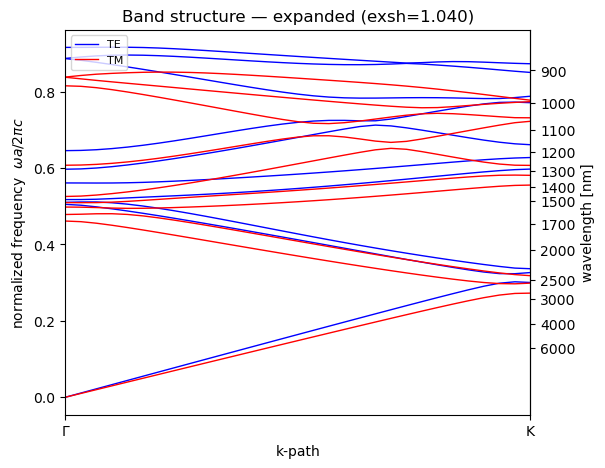

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bands(freqs_te_exp, freqs_tm_exp, f'Band structure — expanded (exsh={exsh_expanded:.3f})', ax=ax)
plt.show()

## 4. MPB — Band structure, shrunken (exsh = 0.95)

In [9]:
freqs_te_shr, freqs_tm_shr = run_mpb(exsh_shrunken)
print_degeneracy_check(freqs_te_shr, 'shrunken')

shrunken: TE frequencies at Gamma = [0.      0.50156 0.51348 0.53361 0.54981 0.59607 0.64204 0.86819 0.87266
 0.88783]
  band 1 -> 2: 0.00000 -> 0.50156  (rel. diff 100.00%)
  band 2 -> 3: 0.50156 -> 0.51348  (rel. diff 2.32%)
  band 3 -> 4: 0.51348 -> 0.53361  (rel. diff 3.77%)
  band 4 -> 5: 0.53361 -> 0.54981  (rel. diff 2.95%)
  band 5 -> 6: 0.54981 -> 0.59607  (rel. diff 7.76%)
  band 6 -> 7: 0.59607 -> 0.64204  (rel. diff 7.16%)
  band 7 -> 8: 0.64204 -> 0.86819  (rel. diff 26.05%)
  band 8 -> 9: 0.86819 -> 0.87266  (rel. diff 0.51%)  <-- near-degenerate pair
  band 9 -> 10: 0.87266 -> 0.88783  (rel. diff 1.71%)


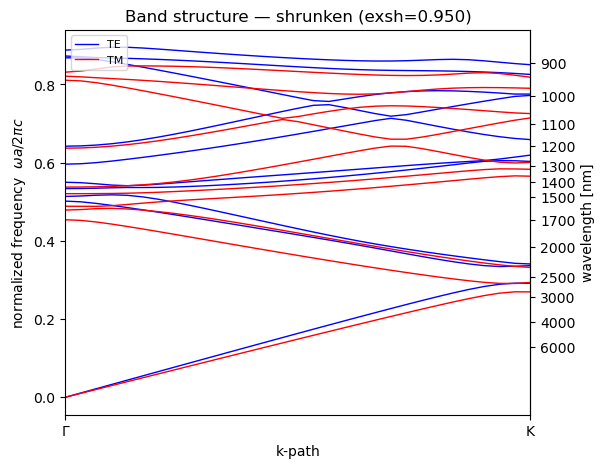

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bands(freqs_te_shr, freqs_tm_shr, f'Band structure — shrunken (exsh={exsh_shrunken:.3f})', ax=ax)
plt.show()

## 5. TE band gap → wavelength

We look for a TE gap near the target wavelength (`lambda_target_nm` above),
scanning all adjacent band-index pairs (not assuming a fixed index). Note: since
we only sampled Γ→K, a "gap" here means "no TE bands cross this frequency
along Γ→K" — a necessary but not sufficient condition for a full-BZ gap
(K→M→Γ isn't checked yet, per your instruction that this isn't needed now).

In [11]:
def find_band_gaps(freqs):
    bmin = freqs.min(axis=0)
    bmax = freqs.max(axis=0)
    gaps = []
    for n in range(len(bmax) - 1):
        if bmax[n] < bmin[n + 1]:
            lo, hi = bmax[n], bmin[n + 1]
            center = 0.5 * (lo + hi)
            gaps.append(dict(band_index=n, f_lower=lo, f_upper=hi,
                              f_center=center, ratio=(hi - lo) / center))
    return gaps

def pick_gap(gaps, target_f):
    return min(gaps, key=lambda g: abs(g['f_center'] - target_f)) if gaps else None

target_f = a0_nm / lambda_target_nm
gaps_exp = find_band_gaps(freqs_te_exp)
gaps_shr = find_band_gaps(freqs_te_shr)

print(f"Target normalized frequency for lambda={lambda_target_nm:.1f}nm at a0={a0_nm}nm: {target_f:.4f}\n")
print(f"All TE gaps (Gamma->K only) -- expanded (exsh={exsh_expanded:.3f}): {'(none found)' if not gaps_exp else ''}")
for g in gaps_exp:
    print(f"  bands {g['band_index']+1}-{g['band_index']+2}: "
          f"f = {g['f_lower']:.4f}-{g['f_upper']:.4f}  (center {g['f_center']:.4f}, "
          f"width {g['ratio']*100:.2f}%,  lambda_center = {a0_nm/g['f_center']:.1f} nm)")

print(f"\nAll TE gaps (Gamma->K only) -- shrunken (exsh={exsh_shrunken:.3f}): {'(none found)' if not gaps_shr else ''}")
for g in gaps_shr:
    print(f"  bands {g['band_index']+1}-{g['band_index']+2}: "
          f"f = {g['f_lower']:.4f}-{g['f_upper']:.4f}  (center {g['f_center']:.4f}, "
          f"width {g['ratio']*100:.2f}%,  lambda_center = {a0_nm/g['f_center']:.1f} nm)")

gap_exp = pick_gap(gaps_exp, target_f)
gap_shr = pick_gap(gaps_shr, target_f)

if gap_exp is None or gap_shr is None:
    print("\nNO TE band gap found near the target for one or both exsh values.")
else:
    lambda_center_exp = a0_nm / gap_exp['f_center']
    lambda_center_shr = a0_nm / gap_shr['f_center']
    print(f"\nGap nearest target ({lambda_target_nm:.1f} nm):")
    print(f"  expanded: bands {gap_exp['band_index']+1}-{gap_exp['band_index']+2}, "
          f"center={gap_exp['f_center']:.4f}, lambda={lambda_center_exp:.1f} nm, width={gap_exp['ratio']*100:.2f}%")
    print(f"  shrunken: bands {gap_shr['band_index']+1}-{gap_shr['band_index']+2}, "
          f"center={gap_shr['f_center']:.4f}, lambda={lambda_center_shr:.1f} nm, width={gap_shr['ratio']*100:.2f}%")

Target normalized frequency for lambda=1421.5nm at a0=770.0nm: 0.5417

All TE gaps (Gamma->K only) -- expanded (exsh=1.040): 
  bands 1-2: f = 0.3022-0.3235  (center 0.3129, width 6.79%,  lambda_center = 2461.2 nm)
  bands 3-4: f = 0.5113-0.5176  (center 0.5144, width 1.21%,  lambda_center = 1496.8 nm)
  bands 7-8: f = 0.7728-0.7820  (center 0.7774, width 1.19%,  lambda_center = 990.5 nm)

All TE gaps (Gamma->K only) -- shrunken (exsh=0.950): 
  bands 1-2: f = 0.2917-0.3343  (center 0.3130, width 13.61%,  lambda_center = 2460.2 nm)
  bands 3-4: f = 0.5176-0.5336  (center 0.5256, width 3.04%,  lambda_center = 1464.9 nm)

Gap nearest target (1421.5 nm):
  expanded: bands 3-4, center=0.5144, lambda=1496.8 nm, width=1.21%
  shrunken: bands 3-4, center=0.5256, lambda=1464.9 nm, width=3.04%


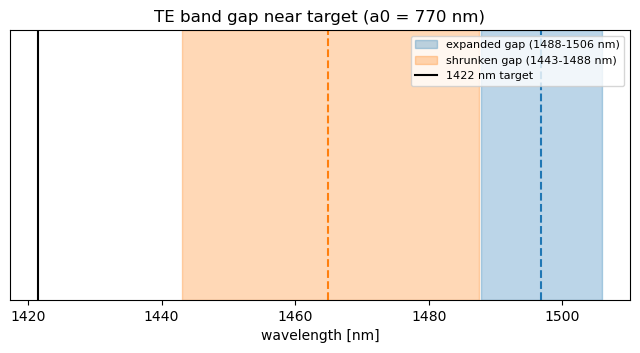

In [12]:
# Visualization: TE band gap zoom, wavelength axis
fig, ax = plt.subplots(figsize=(8, 3.5))
for g, label, color in [(gap_exp, 'expanded', 'C0'), (gap_shr, 'shrunken', 'C1')]:
    if g is None:
        continue
    lam_lower = a0_nm / g['f_upper']
    lam_upper = a0_nm / g['f_lower']
    ax.axvspan(lam_lower, lam_upper, color=color, alpha=0.3,
               label=f'{label} gap ({lam_lower:.0f}-{lam_upper:.0f} nm)')
    ax.axvline(a0_nm / g['f_center'], color=color, lw=1.5, ls='--')

ax.axvline(lambda_target_nm, color='k', lw=1.5, label=f'{lambda_target_nm:.0f} nm target')
ax.set_xlabel('wavelength [nm]')
ax.set_yticks([])
ax.set_title(f'TE band gap near target (a0 = {a0_nm:.0f} nm)')
ax.legend(loc='upper right', fontsize=8)
plt.show()

## 6. Quick parameter exploration (tune further here)

Same tool as before, now defaulting to the validated paper-based parameters —
use it to fine-tune further (e.g. checking sensitivity to `tA_ratio`/`tB_ratio`)
without touching the main parameter cell.

In [13]:
def explore_bandstructure(tA_ratio, tB_ratio, exsh, resolution=24, nb=8, num_kpoints_local=15):
    geometry, size = tile_unitcells(1.0, exsh, tA_ratio, tB_ratio, 3, 3)
    sim = mp.Simulation(cell_size=size, resolution=48, geometry=geometry,
                         default_material=mp.Medium(epsilon=eps_si), dimensions=2)
    sim.init_sim()
    eps = sim.get_array(center=mp.Vector3(0, 0, 0), size=size, component=mp.Dielectric)
    extent = [-size.x/2, size.x/2, -size.y/2, size.y/2]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(eps.T, extent=extent, origin='lower', cmap='binary')
    rect_width, rect_height = 1.0, np.sqrt(3)
    axes[0].add_patch(patches.Rectangle((-rect_width/2, -rect_height/2), rect_width, rect_height,
                                         linewidth=1.5, linestyle='--', edgecolor='red', facecolor='none'))
    axes[0].set_xlim(-rect_width/2*1.15, rect_width/2*1.15)
    axes[0].set_ylim(-rect_height/2*1.15, rect_height/2*1.15)
    axes[0].set_aspect('equal')
    axes[0].set_xlabel('x / a0'); axes[0].set_ylabel('y / a0')
    axes[0].set_title(f'tA={tA_ratio:.4f}, tB={tB_ratio:.4f}, exsh={exsh:.4f}')

    kpts_local = mp.interpolate(num_kpoints_local, [mp.Vector3(0,0,0), mp.Vector3(2/3,1/3,0)])
    geom = make_unitcell_geometry(1.0, exsh, tA_ratio, tB_ratio)
    ms = mpb.ModeSolver(geometry=geom, geometry_lattice=geometry_lattice,
                         resolution=resolution, num_bands=nb,
                         default_material=mp.Medium(epsilon=eps_si),
                         dimensions=2, k_points=kpts_local)
    ms.run_te()
    freqs_te = np.array(ms.all_freqs)
    ms.run_tm()
    freqs_tm = np.array(ms.all_freqs)
    plot_bands(freqs_te, freqs_tm, f'exsh={exsh:.4f}', ax=axes[1])
    plt.tight_layout()
    plt.show()

    gaps = find_band_gaps(freqs_te)
    if gaps:
        print(f"Found {len(gaps)} TE gap(s) (Gamma->K only):")
        for g in gaps:
            print(f"  bands {g['band_index']+1}-{g['band_index']+2}: "
                  f"f={g['f_lower']:.4f}-{g['f_upper']:.4f} (center {g['f_center']:.4f}, "
                  f"width {g['ratio']*100:.2f}%, lambda={a0_nm/g['f_center']:.1f} nm)")
    else:
        print("No TE band gap found with these parameters.")
    return freqs_te, freqs_tm, gaps

Example call (same parameters as the validated main run above):

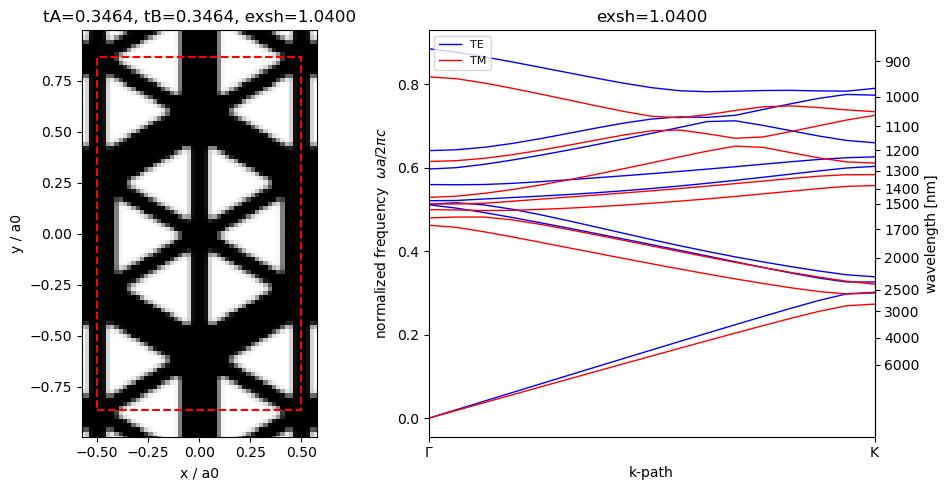

Found 3 TE gap(s) (Gamma->K only):
  bands 1-2: f=0.3018-0.3263 (center 0.3141, width 7.82%, lambda=2451.7 nm)
  bands 3-4: f=0.5162-0.5211 (center 0.5186, width 0.95%, lambda=1484.7 nm)
  bands 7-8: f=0.7756-0.7821 (center 0.7789, width 0.83%, lambda=988.6 nm)


In [14]:
_ = explore_bandstructure(tA_ratio=tA_ratio, tB_ratio=tB_ratio, exsh=exsh_expanded)